<a href="https://colab.research.google.com/github/joyjit-das/sof-tiu-ai-lab/blob/main/ai_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 2: The Water Jug Problem (Solved using BFS)
Problem Statement:
You are given two jugs: Jug A with a capacity of 4 litres, and Jug B with a capacity of 3 litres. Neither jug has any markings on it. Using only the following operations — (i) fill a jug completely, (ii) empty a jug completely, (iii) pour water from one jug into the other until either the first jug is empty or the second jug is full — determine the minimum sequence of steps needed to measure out exactly 2 litres of water in any one jug.

Optimal Solution Found in 4 Steps:

Step 0: Start (0, 0)           -> Jug A: 0L, Jug B: 0L
Step 1: Fill Jug B             -> Jug A: 0L, Jug B: 3L
Step 2: Pour Jug B -> Jug A    -> Jug A: 3L, Jug B: 0L
Step 3: Fill Jug B             -> Jug A: 3L, Jug B: 3L
Step 4: Pour Jug B -> Jug A    -> Jug A: 4L, Jug B: 2L


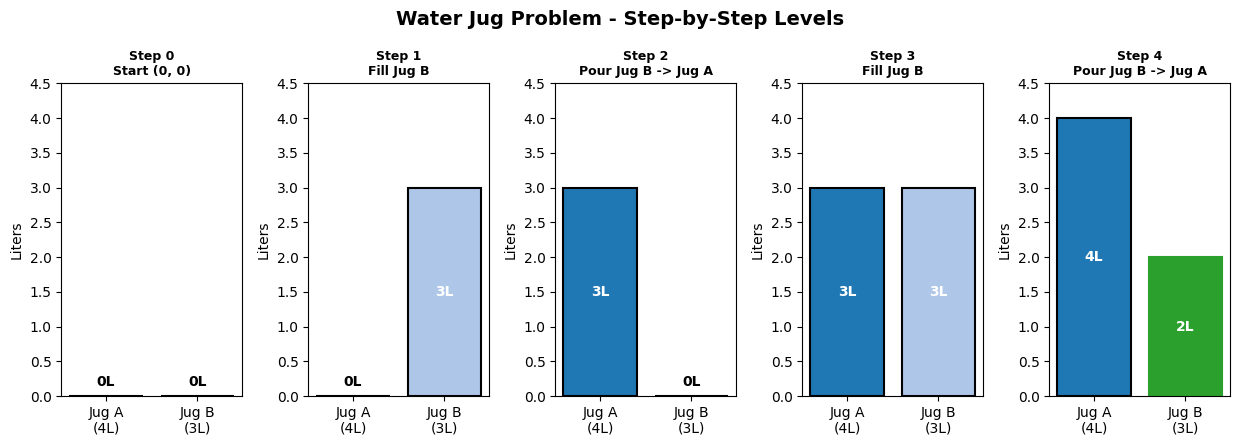

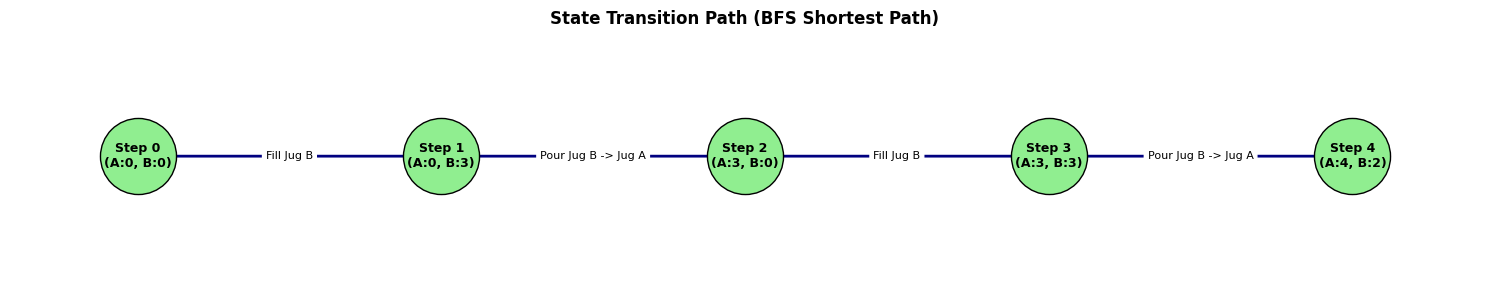

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Maximum capacities
CAP_A = 4
CAP_B = 3
TARGET = 2

# 1. BFS Algorithm to find the shortest path
def solve_water_jug_bfs():
    # Initial state: (jug_a=0, jug_b=0)
    start_state = (0, 0)

    # Queue stores tuple: (current_state, path_taken)
    queue = [(start_state, [(start_state, "Start (0, 0)")])]
    visited = set([start_state])

    while len(queue) > 0:
        (a, b), path = queue.pop(0)

        # Check if target state is reached
        if a == TARGET or b == TARGET:
            return path

        # Define all 6 valid state transition operations
        possible_moves = [
            ((CAP_A, b), "Fill Jug A"),                       # Fill A
            ((a, CAP_B), "Fill Jug B"),                       # Fill B
            ((0, b), "Empty Jug A"),                          # Empty A
            ((a, 0), "Empty Jug B"),                          # Empty B
            # Pour A -> B
            ((a - min(a, CAP_B - b), b + min(a, CAP_B - b)), "Pour Jug A -> Jug B"),
            # Pour B -> A
            ((a + min(b, CAP_A - a), b - min(b, CAP_A - a)), "Pour Jug B -> Jug A")
        ]

        for next_state, action in possible_moves:
            if next_state not in visited:
                visited.add(next_state)
                new_path = list(path)
                new_path.append((next_state, action))
                queue.append((next_state, new_path))

    return None

# Find optimal solution
solution_path = solve_water_jug_bfs()

# Print console steps
print(f"Optimal Solution Found in {len(solution_path) - 1} Steps:\n")
for step, (state, action) in enumerate(solution_path):
    print(f"Step {step}: {action:<22} -> Jug A: {state[0]}L, Jug B: {state[1]}L")

# 2. Visual Plotting Functions
def plot_solution(path):
    steps = len(path)

    # Plot 1: Jug Water Level Visualization
    fig, axes = plt.subplots(1, steps, figsize=(2.5 * steps, 4.5))
    if steps == 1:
        axes = [axes]

    for i, (state, action) in enumerate(path):
        a, b = state
        ax = axes[i]

        # Draw jug water bars
        bars = ax.bar(['Jug A\n(4L)', 'Jug B\n(3L)'], [a, b], color=['#1f77b4', '#aec7e8'], edgecolor='black', linewidth=1.5)

        # Highlight target 2L
        if a == TARGET:
            bars[0].set_color('#2ca02c')
        if b == TARGET:
            bars[1].set_color('#2ca02c')

        ax.set_ylim(0, 4.5)
        ax.set_ylabel("Liters")
        ax.set_title(f"Step {i}\n{action}", fontsize=9, fontweight='bold')

        # Add labels inside bars
        ax.text(0, a / 2 if a > 0 else 0.2, f"{a}L", ha='center', va='center', color='white' if a > 0 else 'black', fontweight='bold')
        ax.text(1, b / 2 if b > 0 else 0.2, f"{b}L", ha='center', va='center', color='white' if b > 0 else 'black', fontweight='bold')

    plt.suptitle("Water Jug Problem - Step-by-Step Levels", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Plot 2: State Transition Flow Graph
    G = nx.DiGraph()
    pos = {}
    labels = {}
    edge_labels = {}

    for idx, (state, action) in enumerate(path):
        node_name = f"S{idx}: {state}"
        G.add_node(node_name)
        pos[node_name] = (idx * 2, 0)
        labels[node_name] = f"Step {idx}\n(A:{state[0]}, B:{state[1]})"

        if idx > 0:
            prev_node = f"S{idx-1}: {path[idx-1][0]}"
            G.add_edge(prev_node, node_name)
            edge_labels[(prev_node, node_name)] = action

    plt.figure(figsize=(3 * steps, 3))
    nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='lightgreen', edgecolors='black')
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=25, edge_color='navy', width=2)
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_weight='bold')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, rotate=False)

    plt.title("State Transition Path (BFS Shortest Path)", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Render visual diagrams
plot_solution(solution_path)